In [1]:
import sklearn
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import proteinmlutils.featurizer as protfeat

In [2]:
protein_df=pd.read_csv("../data/A0A2Z5U3Z0_9INFA_Doud_2016.csv").sample(n=5000, random_state=42)
protein_df.rename(columns={"mutated_sequence": "protein_sequence"}, inplace=True)
sequence_arr = protein_df['protein_sequence'].tolist()
y_arr = protein_df['DMS_score'].tolist()


(array([4296.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         704.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

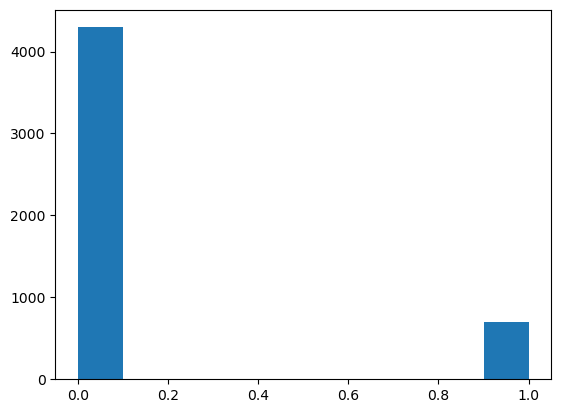

In [3]:
y_discretize_arr=np.digitize(y_arr,bins=[-0.5])
plt.hist(y_discretize_arr)

In [4]:
max_length=sequence_arr[0].__len__()
print("Max length of sequence:", max_length)
X_arr=protfeat.protein_one_hot_encoder(sequence_arr, max_length=max_length, flatten=True)
print(X_arr.shape)  # Check the shape of the one-hot encoded array

Max length of sequence: 565
(5000, 11865)


In [5]:
assert X_arr.shape == (len(protein_df), max_length * 21), "The shape of the one-hot encoded array does not match the expected shape"

In [6]:
embedding_dim = 5  # Set the embedding dimension
embedding_arr, embedding_weight=protfeat.protein_embedding_generator(sequence_arr, max_length, embedding_dim=embedding_dim, flatten=True)

In [15]:
sequence_arr

['...',
 ...]

In [12]:
from torch import nn
import torch
embedding_generator_arr = nn.Embedding(21, embedding_dim=embedding_dim, _weight=embedding_weight)

In [ ]:
amino_acids = 'ACDEFGHIKLMNPQRSTVWY_'
amino_acids_dict = {aa: i for i, aa in enumerate(amino_acids)}

In [21]:
torch.LongTensor(sequence_arr)

ValueError: too many dimensions 'str'

In [ ]:
#output = 
embedding_generator_arr()


TypeError: Embedding.forward() missing 1 required positional argument: 'input'

In [9]:
embedding_arr==embedding_generator_arr

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [7]:
assert embedding_arr.shape == (len(protein_df), max_length * embedding_dim), "The shape of the one-hot encoded array does not match the expected shape"

In [8]:
#from proteinmlutils.ML_trainer import classifier_model_trainer
from proteinmlutils.data_stratifier import data_train_vs_test_splitting
sequence_arr=protein_df["protein_sequence"].tolist()
df=data_train_vs_test_splitting(X_arr, y_discretize_arr, sequence_arr, test_size=0.5)




Training+validation sample size: 2500
Test sample size: 2500


In [9]:
df.rename(columns={"sequence":"protein_sequence"}, inplace=True)
protein_df_combined=protein_df.join(df.set_index("protein_sequence"), on="protein_sequence", how="left")


In [10]:
#convert it to 2D numpy array
X_train = protein_df_combined[protein_df_combined["Train_vs_Test"]=="Train"]["X"]
X_train = np.array(X_train.tolist())
X_test=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Test"]["X"]
X_test = np.array(X_test.tolist())
y_train=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Train"]["y"].to_numpy()
y_test=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Test"]["y"].to_numpy()


In [11]:
from proteinmlutils import model_trainer
clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train)

rf_classifier, results_df = clf_trainer.RandomForestClassifier_trainer(training_mode="default")

y_pred = rf_classifier.predict(X_test)

Score on training: Recall= 1.0 Precision= 1.0 F1 score= 1.0


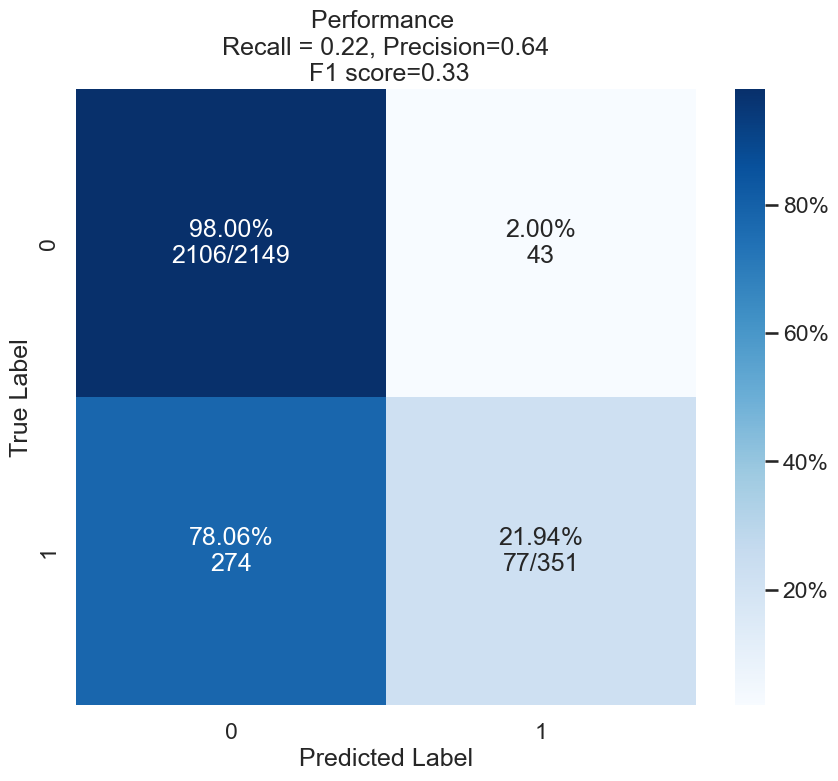

In [12]:
from proteinmlutils import model_eval
folder_name = "../output/DMS_Random_Forest_classifier_results"
model_eval.save_classification_report(y_test, y_pred, folder_name)
model_eval.save_confusion_matrix(y_test,y_pred, foldername=folder_name, labels=[0,1])

In [13]:
## Cross-validation
kwargs = {}
kwargs['scoring'] = ["f1", "precision", "recall", "accuracy"]
kwargs['n_iter'] = 5
kwargs['primary_scoring'] = 'f1'


clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train, **kwargs)
rf_classifier, results_df = clf_trainer.RandomForestClassifier_trainer(training_mode="CrossVal")

y_pred = rf_classifier.predict(X_test)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=True, max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.2s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=True, max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.2s


...

/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=False, max_depth=20, min_samples_leaf=3, min_samples_split=2, n_estimators=100; total time=   0.9s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=False, max_depth=20, min_samples_leaf=3, min_samples_split=2, n_estimators=100; total time=   0.9s
Best parameters found:  {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': True}
Score on training: Recall= 0.0 Precision= 0.0 F1 score= 0.0


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## XGBoost classifier


In [14]:
from proteinmlutils import model_trainer
n_iter=10
clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train, n_iter=n_iter)

xgb_classifier, results_df = clf_trainer.XGBoostClassifier_trainer(training_mode="default", N_categories=2)

y_pred = xgb_classifier.predict(X_test)

Score on training: Recall= 0.039660056657223795 Precision= 0.7777777777777778 F1 score= 0.07547169811320754


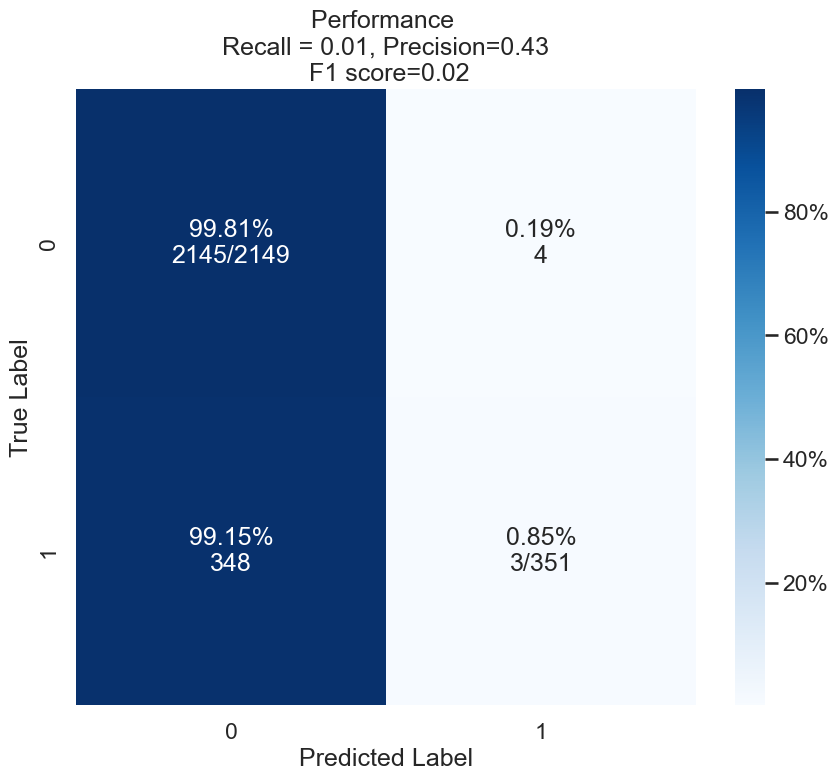

In [15]:
from proteinmlutils import model_eval
folder_name = "../output/DMS_XGBoost_classifier_results"
model_eval.save_classification_report(y_test, y_pred, folder_name)
model_eval.save_confusion_matrix(y_test,y_pred, foldername=folder_name, labels=[0,1])

In [16]:
from scipy import stats
n_iter=50
clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train, n_iter=n_iter)

param_grid = {'objective':['binary:logistic'], 
                'learning_rate': stats.uniform(0.01,0.1),
            'max_depth': [1,2,5,10,20],
            'min_child_weight': [1,3,5],
            'gamma': stats.uniform(0.0,0.6),
            'subsample':  stats.uniform(0.3,0.6),
            'colsample_bytree': stats.uniform(0.5, 0.4),
            'n_estimators': [30,50,70,100], 'n_jobs':[-1]} 

rf_classifier, results_df = clf_trainer.XGBoostClassifier_trainer(training_mode="CrossVal", N_categories=2, param_grid=param_grid)

y_pred = rf_classifier.predict(X_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END colsample_bytree=0.6534088779388983, gamma=0.023699713688164148, learning_rate=0.02191463297843154, max_depth=10, min_child_weight=1, n_estimators=100, n_jobs=-1, objective=binary:logistic, subsample=0.7207780944523164; total time=   0.6s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END colsample_bytree=0.6534088779388983, gamma=0.023699713688164148, learning_rate=0.02191463297843154, max_depth=10, min_child_weight=1, n_estimators=100, n_jobs=-1, objective=binary:logistic, subsample=0.7207780944523164; total time=   0.7s


...

/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END colsample_bytree=0.7122806469196998, gamma=0.2169400770316882, learning_rate=0.015884463933225738, max_depth=5, min_child_weight=1, n_estimators=30, n_jobs=-1, objective=binary:logistic, subsample=0.49608091144651334; total time=   0.2s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END colsample_bytree=0.7122806469196998, gamma=0.2169400770316882, learning_rate=0.015884463933225738, max_depth=5, min_child_weight=1, n_estimators=30, n_jobs=-1, objective=binary:logistic, subsample=0.49608091144651334; total time=   0.2s
Best parameters found:  {'colsample_bytree': np.float64(0.6534088779388983), 'gamma': np.float64(0.023699713688164148), 'learning_rate': np.float64(0.02191463297843154), 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 100, 'n_jobs': -1, 'objective': 'binary:logistic', 'subsample': np.float64(0.7207780944523164)}
Score on training: Recall= 0.0 Precision= 0.0 F1 score= 0.0


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
